# Testing Bed


In [1]:

from instance_generator import Graph, ProblemInstance, create_test_graphs
from classical_solvers import brute_force_solver, greedy_solver
from metrics import approximation_ratio, compare_solutions
from visualization import store_test_results, plot_results_summary
import time
import logging
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Configure logging
log_filename = f"testing_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(log_filename),
        logging.StreamHandler()  # Also print to console
    ]
)
logger = logging.getLogger(__name__)
logger.info(f"Testing session started. Logs will be saved to {log_filename}")


2026-03-13 14:59:22,082 - INFO - Testing session started. Logs will be saved to testing_20260313_145922.log


In [3]:
def test_solvers_on_graph(graph: Graph, graph_name="Graph"):
    """Test all solvers on a given graph and log results."""
    logger.info("=" * 70)
    logger.info(f"TEST: {graph_name}")
    logger.info(f"Vertices: {graph.E} | Edges: {len(graph.edges)}")
    logger.info(f"Edges: {sorted(graph.edges)}")
    logger.info("=" * 70)
    
    problem = ProblemInstance(graph, k=2)
    results = {}
    
    # Test Brute Force
    logger.info("[1] BRUTE FORCE")
    start = time.time()
    bf_sol, bf_score = brute_force_solver(problem)
    bf_time = time.time() - start
    logger.info(f"    Solution: {bf_sol}")
    logger.info(f"    Score: {bf_score}")
    logger.info(f"    Time: {bf_time*1000:.3f} ms")
    logger.info(f"    ✓ OPTIMAL (garanteed)")
    results['brute_force'] = (bf_sol, bf_score, bf_time)

    # Test Greedy
    logger.info("[2] GREEDY")
    start = time.time()
    greedy_sol, greedy_score = greedy_solver(problem)
    greedy_time = time.time() - start
    logger.info(f"    Solution: {greedy_sol}")
    logger.info(f"    Score: {greedy_score}")
    logger.info(f"    Time: {greedy_time*1000:.3f} ms")
    
    # Compute approximation ratio
    greedy_ratio = approximation_ratio(greedy_score, bf_score)
    logger.info(f"    Quality: {greedy_ratio*100:.1f}% of the optimal")
    results['greedy'] = (greedy_sol, greedy_score, greedy_time)
    

    # logger.info("[3] QAOA (experimental)")
    # start = time.time()
    # qaoa_sol, qaoa_score = qaoa_solver(problem)
    # qaoa_time = time.time() - start
    # logger.info(f"    Solution: {qaoa_sol}")
    # logger.info(f"    Score: {qaoa_score}")
    # logger.info(f"    Time: {qaoa_time*1000:.3f} ms")

    # Summary and comparison
    logger.info("-" * 70)
    comparison = compare_solutions({method: (sol, score) for method, (sol, score, _) in results.items()})
    logger.info(f"Best method: {comparison['best_method'].upper()} with score {comparison['best_value']}")
    
    fastest = min(results.items(), key=lambda x: x[1][2])
    logger.info(f"Fastest: {fastest[0].upper()} ({fastest[1][2]*1000:.3f} ms)")
    
    # Store results for visualization
    store_test_results(graph_name, results)
    
    return results


## Run Tests on All Graphs


2026-03-13 14:59:22,113 - INFO - 
Testing Triangle K3


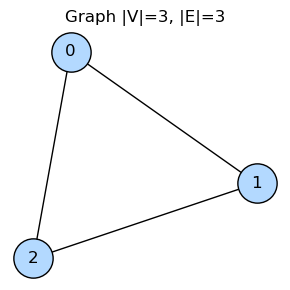

2026-03-13 14:59:22,299 - INFO - ======================================================================
2026-03-13 14:59:22,299 - INFO - TEST: Triangle K3
2026-03-13 14:59:22,300 - INFO - Vertices: 3 | Edges: 3
2026-03-13 14:59:22,301 - INFO - Edges: [(0, 1), (0, 2), (1, 2)]
2026-03-13 14:59:22,301 - INFO - ======================================================================
2026-03-13 14:59:22,302 - INFO - [1] BRUTE FORCE
2026-03-13 14:59:22,303 - INFO -     Solution: [0, 0, 0]
2026-03-13 14:59:22,303 - INFO -     Score: 3
2026-03-13 14:59:22,304 - INFO -     Time: 0.028 ms
2026-03-13 14:59:22,305 - INFO -     ✓ OPTIMAL (garanteed)
2026-03-13 14:59:22,306 - INFO - [2] GREEDY
2026-03-13 14:59:22,306 - INFO -     Solution: [0, 0, 0]
2026-03-13 14:59:22,307 - INFO -     Score: 3
2026-03-13 14:59:22,308 - INFO -     Time: 0.020 ms
2026-03-13 14:59:22,309 - INFO -     Quality: 100.0% of the optimal
2026-03-13 14:59:22,310 - INFO - ---------------------------------------------------------

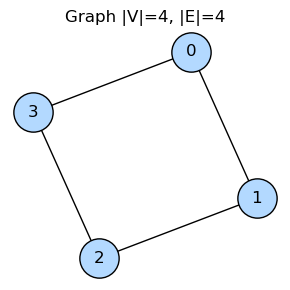

2026-03-13 14:59:22,435 - INFO - ======================================================================
2026-03-13 14:59:22,435 - INFO - TEST: Square C4
2026-03-13 14:59:22,436 - INFO - Vertices: 4 | Edges: 4
2026-03-13 14:59:22,437 - INFO - Edges: [(0, 1), (0, 3), (1, 2), (2, 3)]
2026-03-13 14:59:22,438 - INFO - ======================================================================
2026-03-13 14:59:22,439 - INFO - [1] BRUTE FORCE
2026-03-13 14:59:22,440 - INFO -     Solution: [0, 0, 0, 0]
2026-03-13 14:59:22,441 - INFO -     Score: 6
2026-03-13 14:59:22,442 - INFO -     Time: 0.060 ms
2026-03-13 14:59:22,443 - INFO -     ✓ OPTIMAL (garanteed)
2026-03-13 14:59:22,444 - INFO - [2] GREEDY
2026-03-13 14:59:22,445 - INFO -     Solution: [0, 0, 0, 0]
2026-03-13 14:59:22,446 - INFO -     Score: 6
2026-03-13 14:59:22,447 - INFO -     Time: 0.065 ms
2026-03-13 14:59:22,447 - INFO -     Quality: 100.0% of the optimal
2026-03-13 14:59:22,448 - INFO - ---------------------------------------------

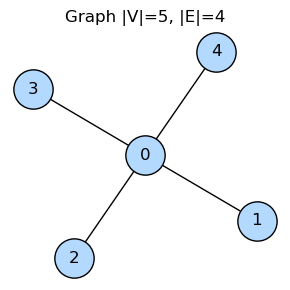

2026-03-13 14:59:22,564 - INFO - ======================================================================
2026-03-13 14:59:22,565 - INFO - TEST: Star S4
2026-03-13 14:59:22,566 - INFO - Vertices: 5 | Edges: 4
2026-03-13 14:59:22,567 - INFO - Edges: [(0, 1), (0, 2), (0, 3), (0, 4)]
2026-03-13 14:59:22,568 - INFO - ======================================================================
2026-03-13 14:59:22,569 - INFO - [1] BRUTE FORCE
2026-03-13 14:59:22,570 - INFO -     Solution: [0, 0, 0, 0, 0]
2026-03-13 14:59:22,570 - INFO -     Score: 10
2026-03-13 14:59:22,571 - INFO -     Time: 0.142 ms
2026-03-13 14:59:22,572 - INFO -     ✓ OPTIMAL (garanteed)
2026-03-13 14:59:22,573 - INFO - [2] GREEDY
2026-03-13 14:59:22,573 - INFO -     Solution: [0, 0, 0, 0, 0]
2026-03-13 14:59:22,574 - INFO -     Score: 10
2026-03-13 14:59:22,574 - INFO -     Time: 0.051 ms
2026-03-13 14:59:22,575 - INFO -     Quality: 100.0% of the optimal
2026-03-13 14:59:22,576 - INFO - ---------------------------------------

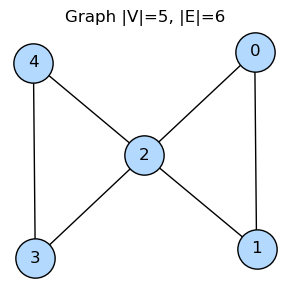

2026-03-13 14:59:22,714 - INFO - ======================================================================
2026-03-13 14:59:22,715 - INFO - TEST: Butterfly
2026-03-13 14:59:22,716 - INFO - Vertices: 5 | Edges: 6
2026-03-13 14:59:22,717 - INFO - Edges: [(0, 1), (0, 2), (1, 2), (2, 3), (2, 4), (3, 4)]
2026-03-13 14:59:22,717 - INFO - ======================================================================
2026-03-13 14:59:22,718 - INFO - [1] BRUTE FORCE
2026-03-13 14:59:22,719 - INFO -     Solution: [0, 0, 0, 0, 0]
2026-03-13 14:59:22,719 - INFO -     Score: 10
2026-03-13 14:59:22,720 - INFO -     Time: 0.138 ms
2026-03-13 14:59:22,720 - INFO -     ✓ OPTIMAL (garanteed)
2026-03-13 14:59:22,721 - INFO - [2] GREEDY
2026-03-13 14:59:22,721 - INFO -     Solution: [0, 0, 0, 0, 0]
2026-03-13 14:59:22,722 - INFO -     Score: 10
2026-03-13 14:59:22,723 - INFO -     Time: 0.050 ms
2026-03-13 14:59:22,723 - INFO -     Quality: 100.0% of the optimal
2026-03-13 14:59:22,724 - INFO - ---------------------

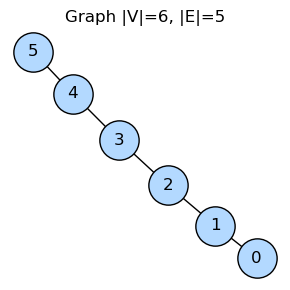

2026-03-13 14:59:22,854 - INFO - ======================================================================
2026-03-13 14:59:22,854 - INFO - TEST: Path P6
2026-03-13 14:59:22,855 - INFO - Vertices: 6 | Edges: 5
2026-03-13 14:59:22,856 - INFO - Edges: [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5)]
2026-03-13 14:59:22,857 - INFO - ======================================================================
2026-03-13 14:59:22,857 - INFO - [1] BRUTE FORCE
2026-03-13 14:59:22,858 - INFO -     Solution: [0, 0, 0, 0, 0, 0]
2026-03-13 14:59:22,859 - INFO -     Score: 15
2026-03-13 14:59:22,860 - INFO -     Time: 0.342 ms
2026-03-13 14:59:22,860 - INFO -     ✓ OPTIMAL (garanteed)
2026-03-13 14:59:22,861 - INFO - [2] GREEDY
2026-03-13 14:59:22,862 - INFO -     Solution: [0, 0, 0, 0, 0, 0]
2026-03-13 14:59:22,862 - INFO -     Score: 15
2026-03-13 14:59:22,863 - INFO -     Time: 0.097 ms
2026-03-13 14:59:22,864 - INFO -     Quality: 100.0% of the optimal
2026-03-13 14:59:22,864 - INFO - -------------------------

In [4]:
# Create all test graphs
test_graphs = create_test_graphs()

# Run tests on each graph
for graph_name, graph in test_graphs.items():
    logger.info(f"\n{'='*70}\nTesting {graph_name}\n{'='*70}")
    graph.draw()
    test_solvers_on_graph(graph, graph_name)


## Comparison

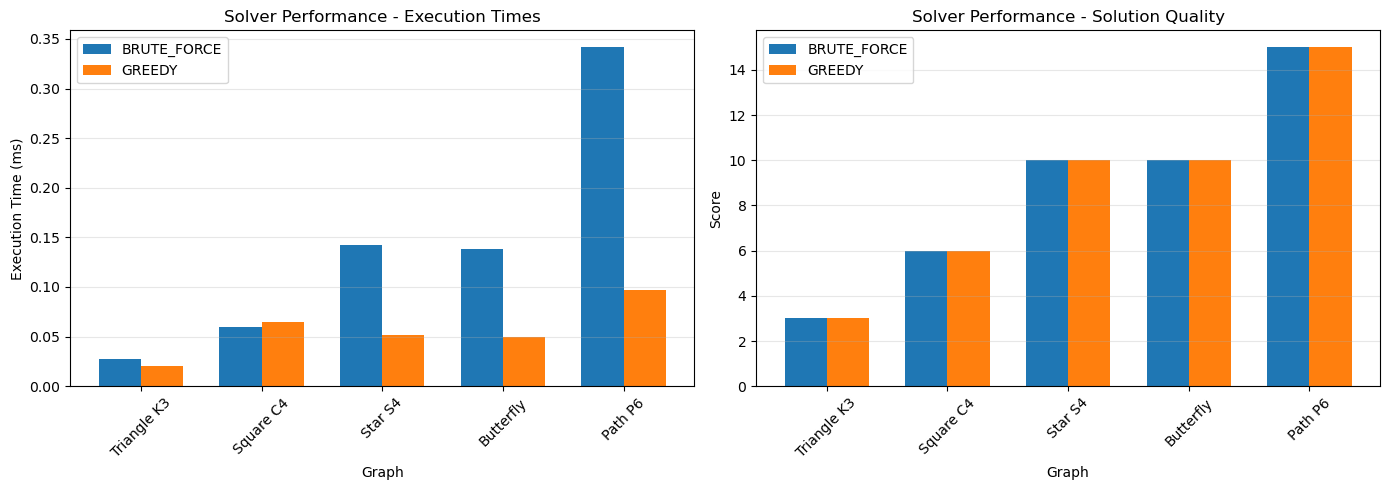

In [5]:
# Final comparison and visualization
plot_results_summary()
